In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
def printQuantFig(target, df):

    df['SMA20'] = df['Close'].rolling(window=20).mean()            #단순이동평균
    df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()    #지수이동평균


    # 2개의 그래프(가격변동, 거래량) 생성
    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.05,
        row_heights=[0.7, 0.3]
    )


    # 캔들차트
    fig.add_trace(
        go.Candlestick(
            x=df.index,
            open=df['Open'],
            high=df['High'],
            low=df['Low'],
            close=df['Close'],
            name=target,

            increasing_line_color='red',
            increasing_fillcolor='red',

            decreasing_line_color='blue',
            decreasing_fillcolor='blue'
        ),
        row=1,
        col=1
    )

    # SMA(20)
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['SMA20'],
            mode='lines',
            name='SMA(20)'
        ),
        row=1,
        col=1
    )


    # EMA(20)
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['EMA20'],
            mode='lines',
            name='EMA(20)'
        ),
        row=1,
        col=1
    )

    # 거래량
    fig.add_trace(
        go.Bar(
            x=df.index,
            y=df['Volume'],
            name='Volume'
        ),
        row=2,
        col=1
    )


    # 차트 설정
    fig.update_layout(
        title= f'{target} Stock Price Movement',
        xaxis_rangeslider_visible=False,
        height=700
    )

    fig.show()

### 캔들차트(애플 2018년도 주가)

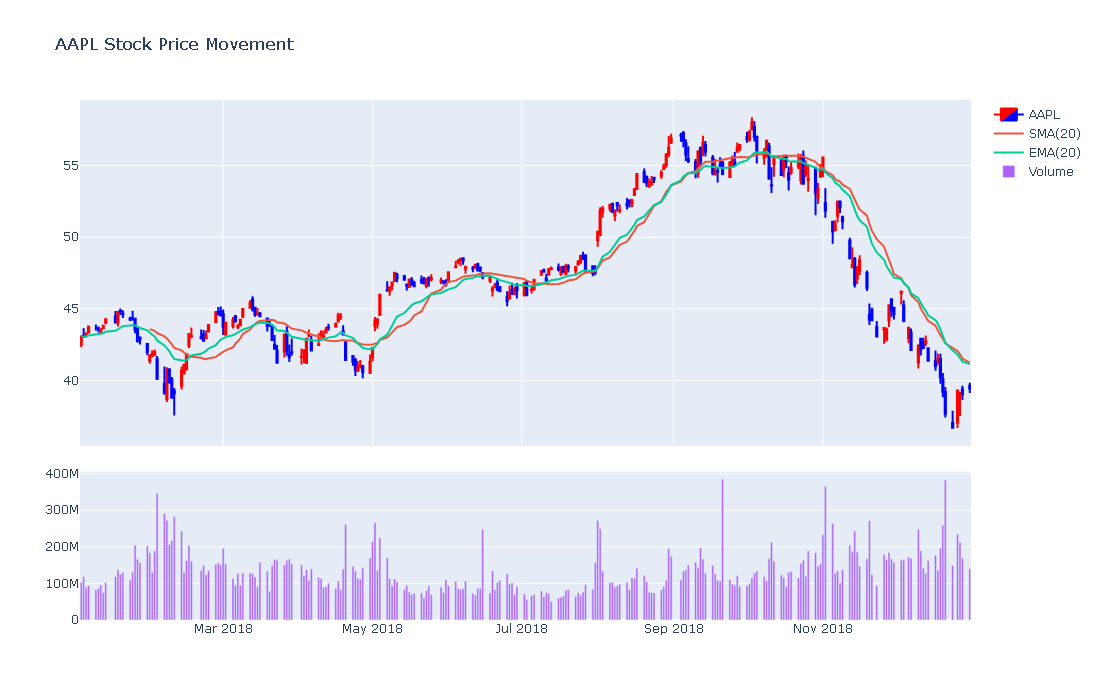

In [3]:
dir_nm = "dailyStock"
target = "AAPL"
file_path = f"{dir_nm}/{target}.csv"

aapl_df = pd.read_csv(file_path, encoding="utf-8")
aapl_df['Date'] = pd.to_datetime(aapl_df['Date'])
aapl_df = aapl_df.set_index("Date")
aapl_df = aapl_df.loc["2018-01-01":"2018-12-31"]

printQuantFig(target, aapl_df)